In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Count missing values
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_percent
})

print(missing_df[missing_df['Missing Count'] > 0])

             Missing Count  Percentage
age                    177   19.865320
embarked                 2    0.224467
deck                   688   77.216611
embark_town              2    0.224467


The 3 Rules:

- < 5% missing → Fill it (mean/median/mode)
- 5–30% missing → Fill carefully or create a flag column
- 30% < missing → Consider dropping the column

In [4]:
# # Check types
# print("Before typr casting")
# print(df.dtypes)

# # Fix if needed
# df['age'] = df['age'].astype(float)
# df['survived'] = df['survived'].astype(int)

# # Convert categorical stored as numbers
# df['pclass'] = df['pclass'].astype('category')

# print("After typr casting")
# print(df.dtypes)


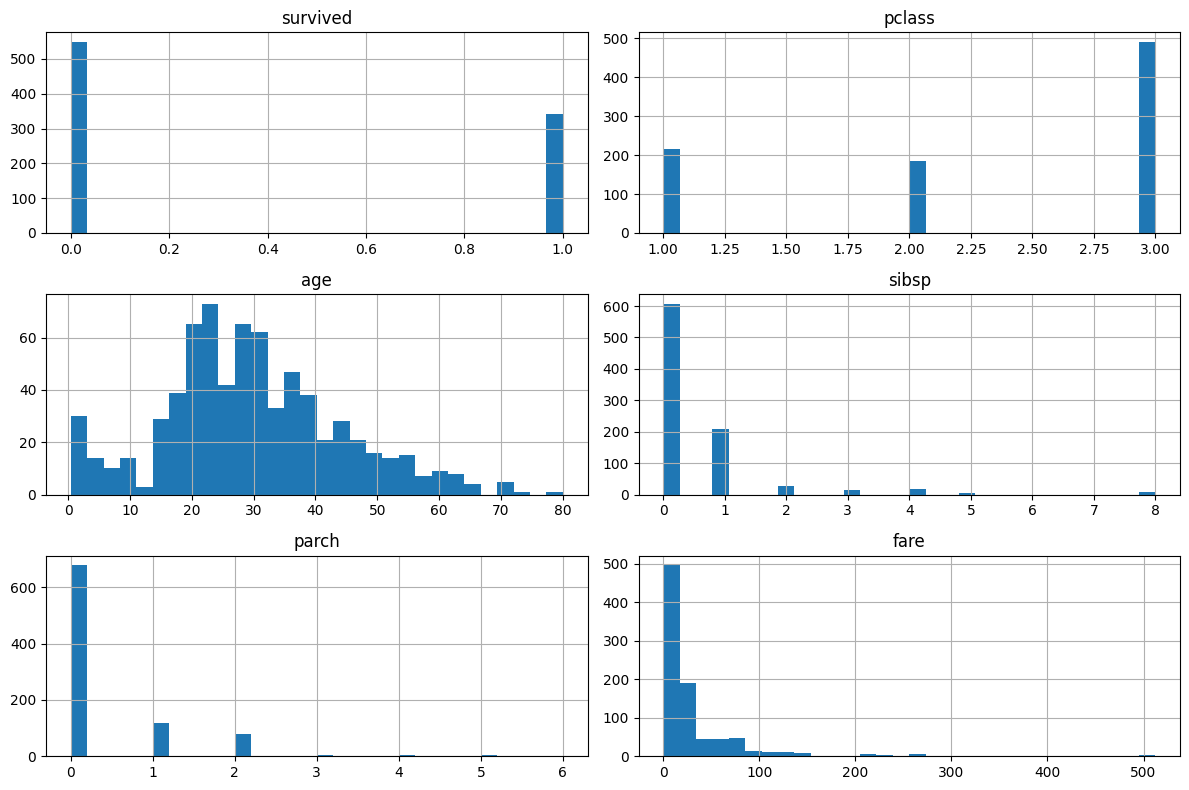

survived      0.478523
pclass       -0.630548
age           0.389108
sibsp         3.695352
parch         2.749117
fare          4.787317
adult_male   -0.420431
alone        -0.420431
dtype: float64


In [5]:
# Numeric columns — check for skewness
df.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

# Check skewness value
print(df.skew(numeric_only=True))
# Rule: skew > 1 or < -1 means heavy skew → may need log transform

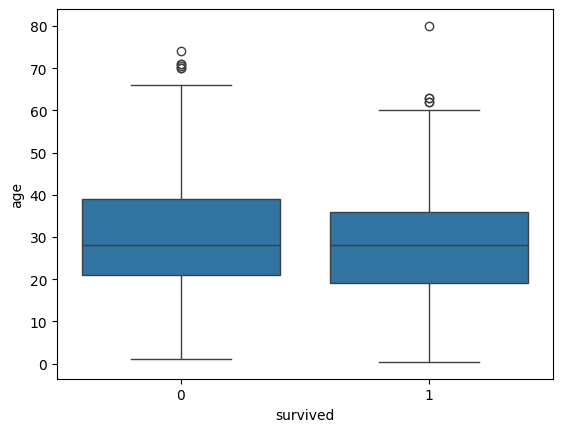

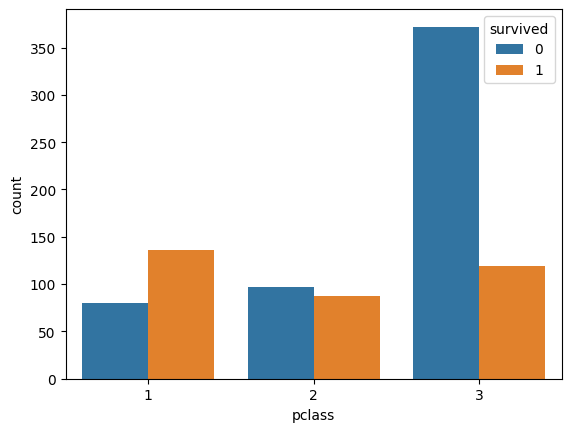

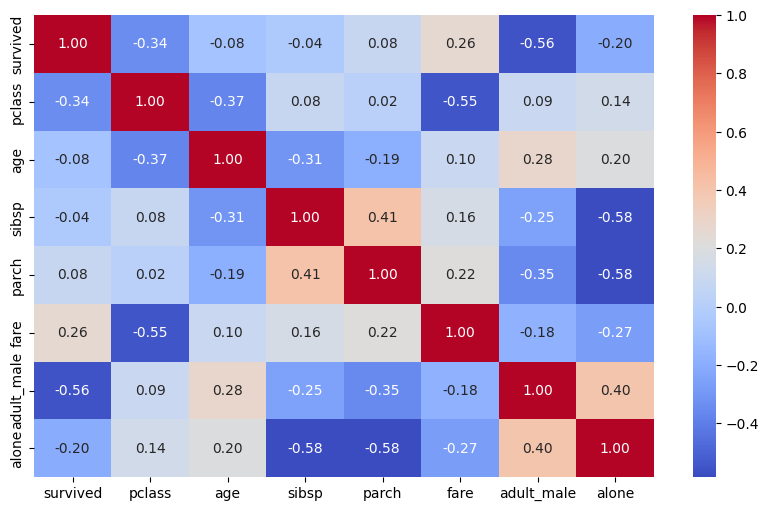

In [6]:
# Target = 'Survived'

# Numeric feature vs target
sns.boxplot(x='survived', y='age', data=df)
plt.show()

# Categorical feature vs target
sns.countplot(x='pclass', hue='survived', data=df)
plt.show()

# Correlation heatmap (most powerful!)
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

Which column has the most missing values? -> deck
Which feature has the highest correlation with Survived? -> fare

In [7]:
df['age'].skew()

np.float64(0.38910778230082704)

# skew > 1 → use MEDIAN
# skew < 1 → use MEAN

In [8]:
df['Age_was_missing'] = df['age'].isnull().astype(int)
df['age'].fillna(df['age'].median(), inplace=True)

C:\Users\nisha\AppData\Local\Temp\ipykernel_16680\2585775383.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['age'].fillna(df['age'].median(), inplace=True)


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: age, Length: 891, dtype: float64

In [9]:
# Most frequent value
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

C:\Users\nisha\AppData\Local\Temp\ipykernel_16680\1537198893.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)


0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: embarked, Length: 891, dtype: str

In [10]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_was_missing
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0


In [11]:
# Drop column if > 30% missing
threshold = 0.3
df = df[df.columns[df.isnull().mean() < threshold]]

# Drop rows with any missing (use carefully!)
df.dropna(inplace=True)

In [12]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,Age_was_missing
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,0


In [13]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]
    print(f"{column}: {len(outliers)} outliers found")
    print(f"  Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
    return lower, upper

lower, upper = detect_outliers_iqr(df, 'age')

age: 8 outliers found
  Lower bound: -7.00, Upper bound: 65.00


In [14]:
# Cap outliers at boundary instead of removing
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower, upper)
    return df

df = cap_outliers(df, 'age')
df = cap_outliers(df, 'fare')

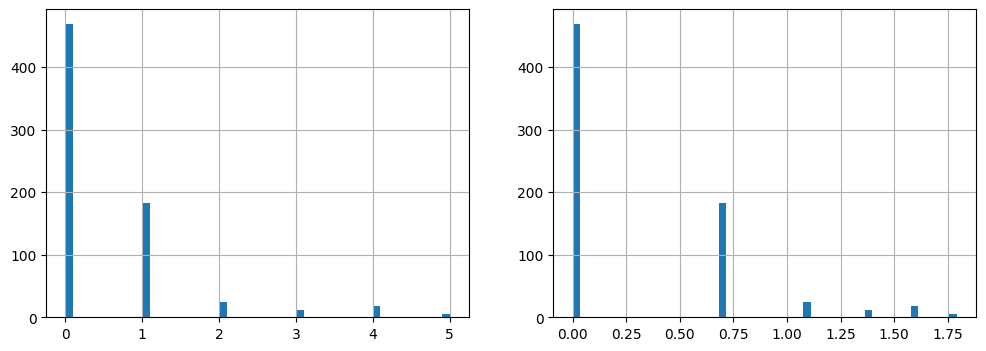

In [15]:
# Compresses large values, reduces outlier effect
df['sibsp_log'] = np.log1p(df['sibsp'])  # log1p handles 0 values safely

# Visualize before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['sibsp'].hist(ax=axes[0], bins=50)
df['sibsp_log'].hist(ax=axes[1], bins=50)
plt.show()

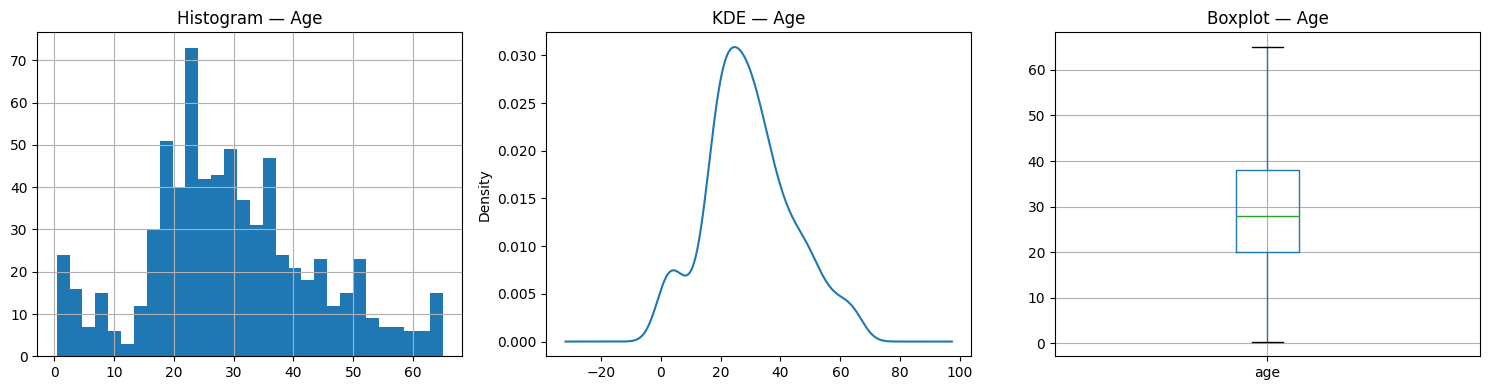

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram — overall shape
df['age'].hist(bins=30, ax=axes[0])
axes[0].set_title('Histogram — Age')

# KDE Plot — smooth distribution curve
df['age'].plot(kind='kde', ax=axes[1])
axes[1].set_title('KDE — Age')

# Boxplot — outliers + spread
df.boxplot(column='age', ax=axes[2])
axes[2].set_title('Boxplot — Age')

plt.tight_layout()
plt.show()

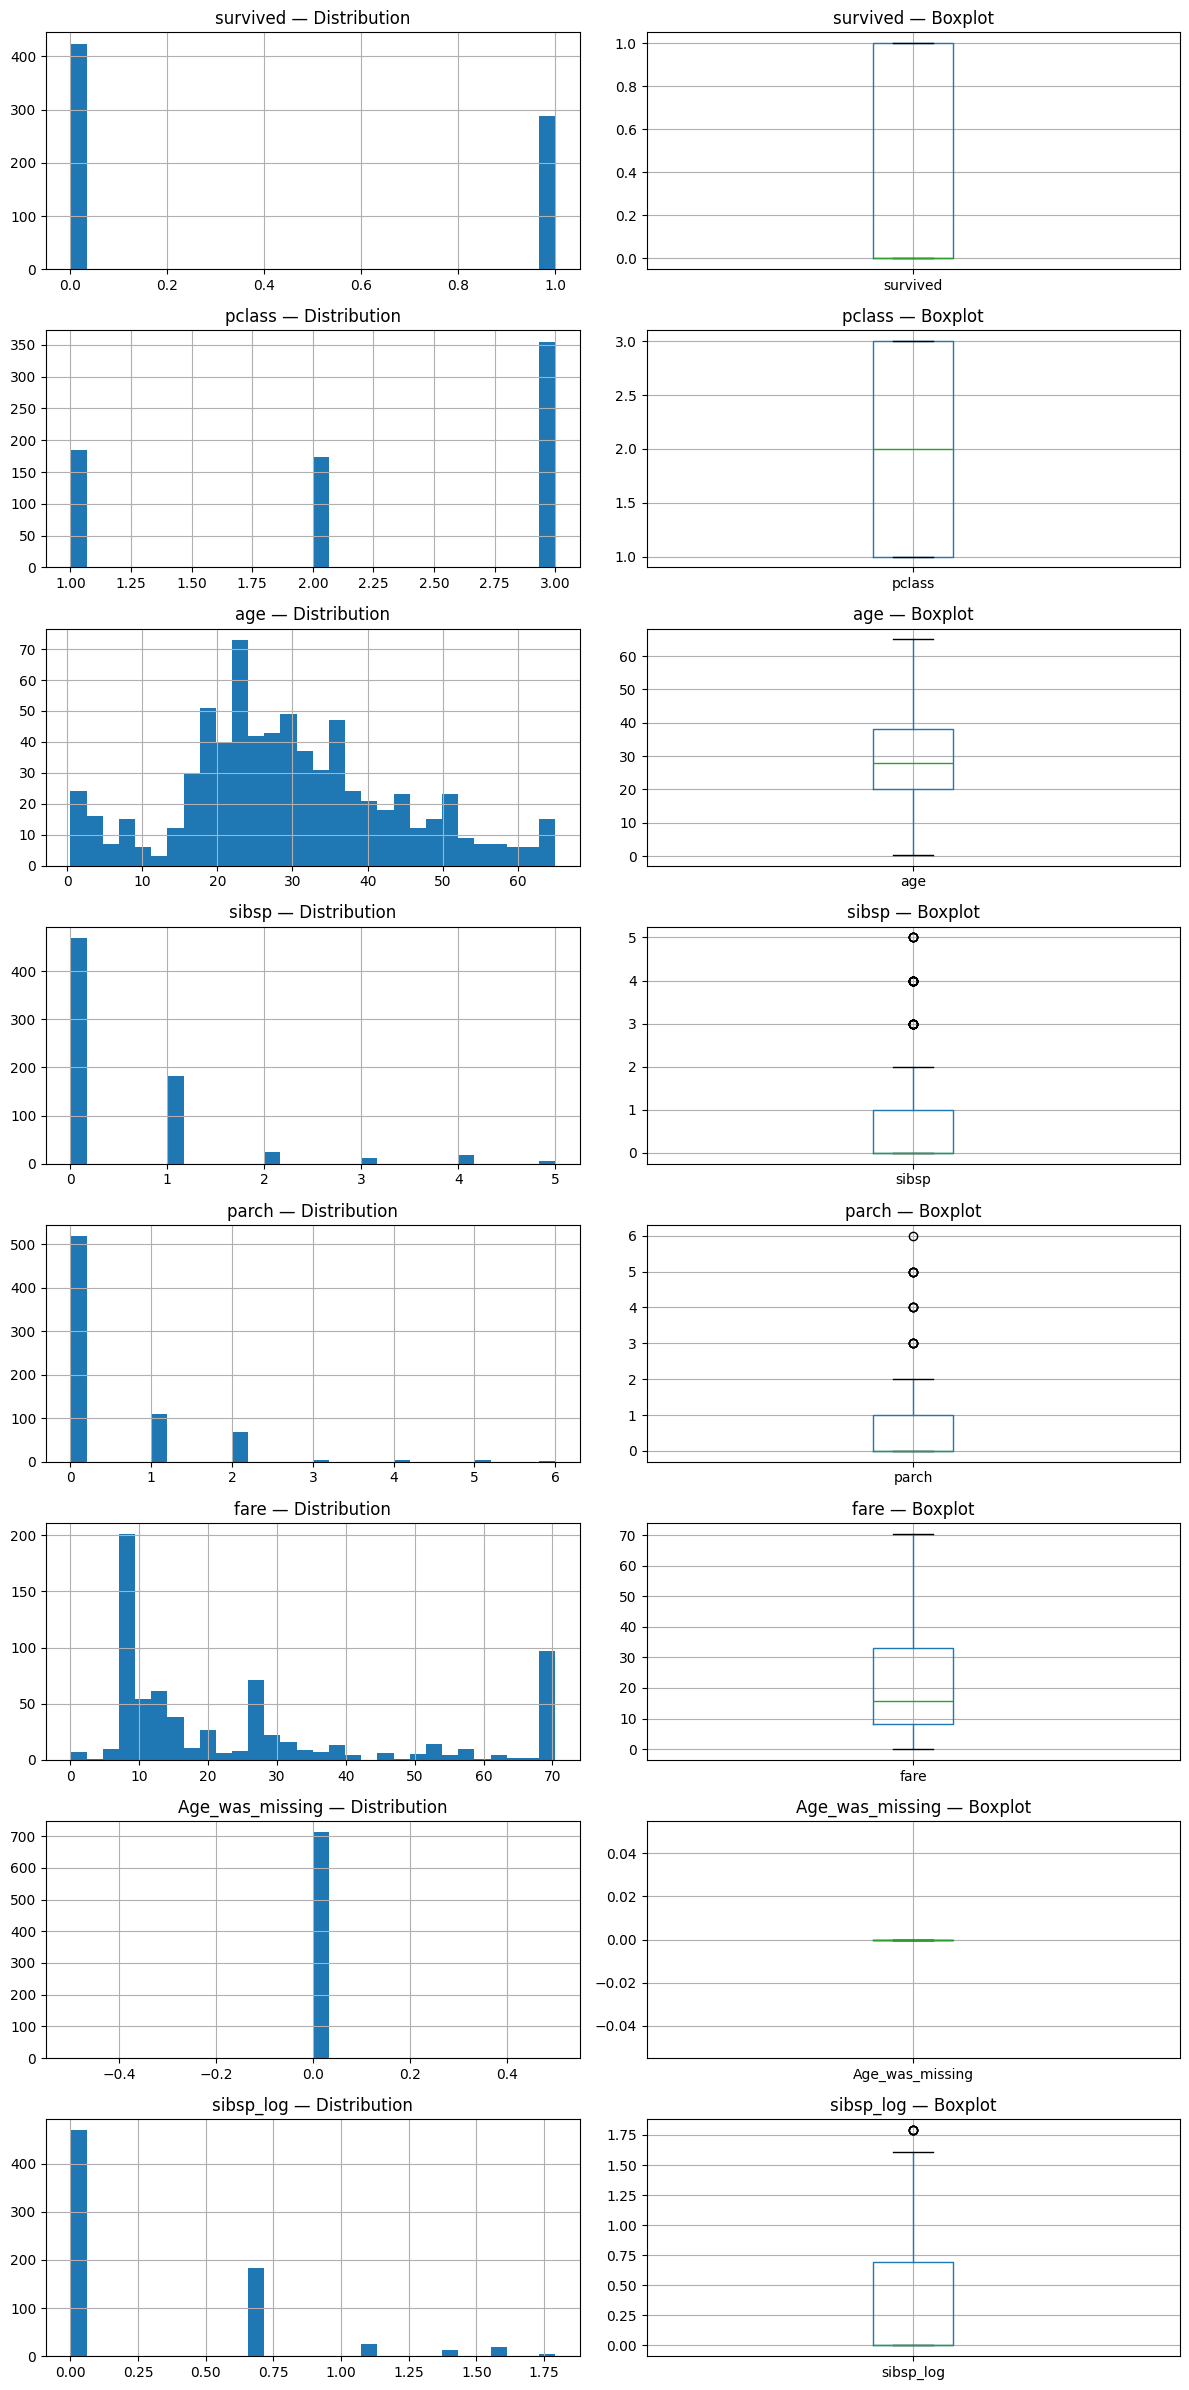

In [17]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(
    nrows=len(numeric_cols), 
    ncols=2, 
    figsize=(12, len(numeric_cols)*3)
)

for i, col in enumerate(numeric_cols):
    # Histogram
    df[col].hist(bins=30, ax=axes[i][0])
    axes[i][0].set_title(f'{col} — Distribution')
    
    # Boxplot
    df.boxplot(column=col, ax=axes[i][1])
    axes[i][1].set_title(f'{col} — Boxplot')

plt.tight_layout()
plt.show()

In [18]:
skewness = df[numeric_cols].skew().sort_values(ascending=False)
print(skewness)

# Color code it
for col, skew in skewness.items():
    if abs(skew) > 1:
        print(f"⚠️  {col}: {skew:.2f} → HIGHLY SKEWED — consider log transform")
    elif abs(skew) > 0.5:
        print(f"🔶 {col}: {skew:.2f} → Moderately skewed")
    else:
        print(f"✅ {col}: {skew:.2f} → Fairly normal")

parch              2.614177
sibsp              2.515107
sibsp_log          1.357673
fare               1.081627
survived           0.390010
age                0.300164
Age_was_missing    0.000000
pclass            -0.475604
dtype: float64
⚠️  parch: 2.61 → HIGHLY SKEWED — consider log transform
⚠️  sibsp: 2.52 → HIGHLY SKEWED — consider log transform
⚠️  sibsp_log: 1.36 → HIGHLY SKEWED — consider log transform
⚠️  fare: 1.08 → HIGHLY SKEWED — consider log transform
✅ survived: 0.39 → Fairly normal
✅ age: 0.30 → Fairly normal
✅ Age_was_missing: 0.00 → Fairly normal
✅ pclass: -0.48 → Fairly normal


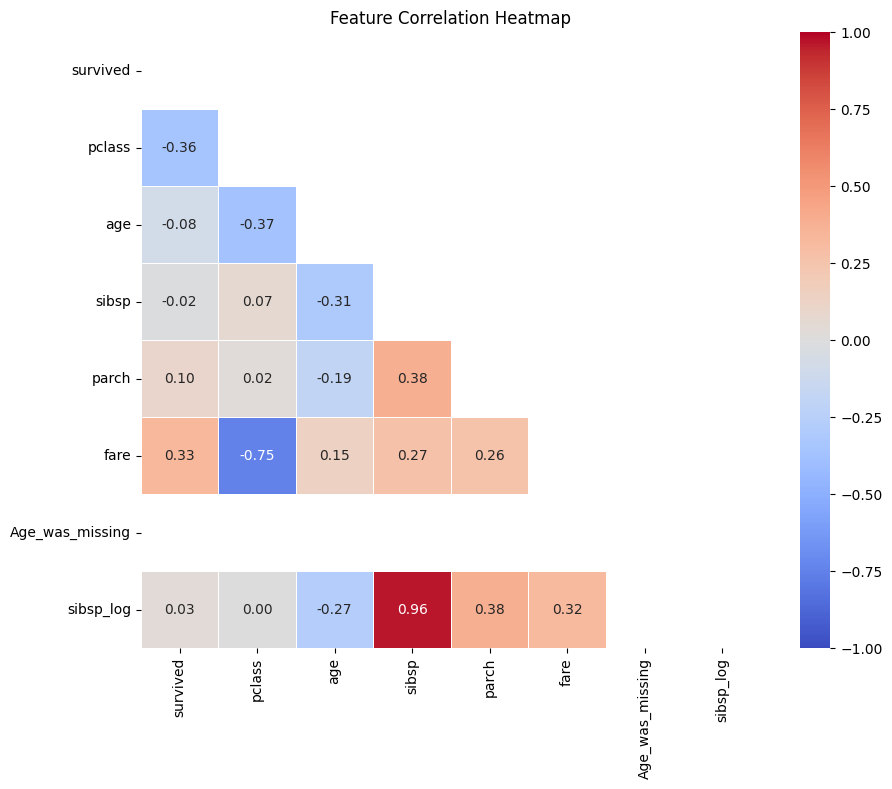

In [19]:
plt.figure(figsize=(10, 8))

# Compute correlation
corr_matrix = df[numeric_cols].corr()

# Create mask for upper triangle (avoid duplicate)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,          # Show numbers
    fmt='.2f',           # 2 decimal places
    cmap='coolwarm',     # Red=positive, Blue=negative
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title('Feature Correlation Heatmap')
plt.show()

📊 Feature correlation with TARGET (Survived):
pclass             0.356462
fare               0.328314
parch              0.095265
age                0.082373
sibsp_log          0.033285
sibsp              0.015523
Age_was_missing         NaN
Name: survived, dtype: float64


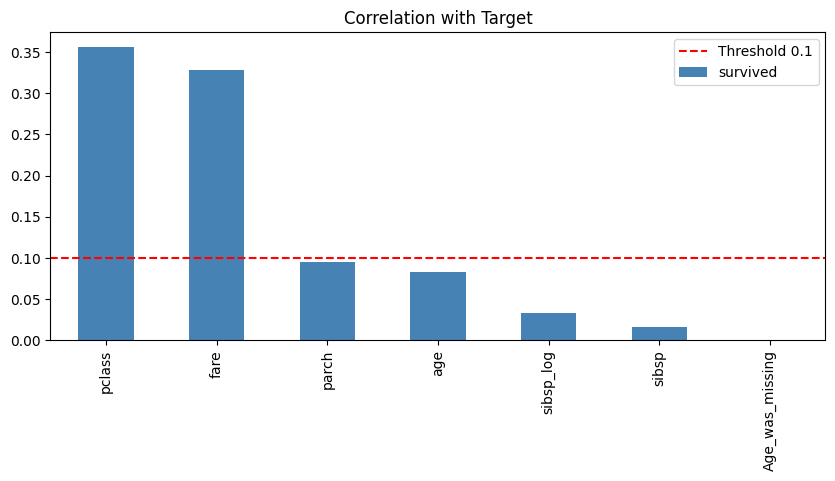

In [20]:
# Most important step before model training!
target_corr = corr_matrix['survived'].drop('survived')
target_corr = target_corr.abs().sort_values(ascending=False)

print("📊 Feature correlation with TARGET (Survived):")
print(target_corr)

# Visualize it
target_corr.plot(kind='bar', figsize=(10, 4), color='steelblue')
plt.title('Correlation with Target')
plt.axhline(y=0.1, color='red', linestyle='--', label='Threshold 0.1')
plt.legend()
plt.show()

💡 Features with correlation < 0.05 with target are often useless — consider dropping them!

In [21]:
# Multicollinearity = two features carry same info
# Bad for Linear/Logistic Regression!

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print("⚠️  High Correlation Pairs Found:")
    print(pd.DataFrame(high_corr_pairs))
else:
    print("✅ No multicollinearity detected")

⚠️  High Correlation Pairs Found:
  Feature 1  Feature 2  Correlation
0     sibsp  sibsp_log     0.961799


C:\Users\nisha\AppData\Local\Temp\ipykernel_16680\1032806790.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


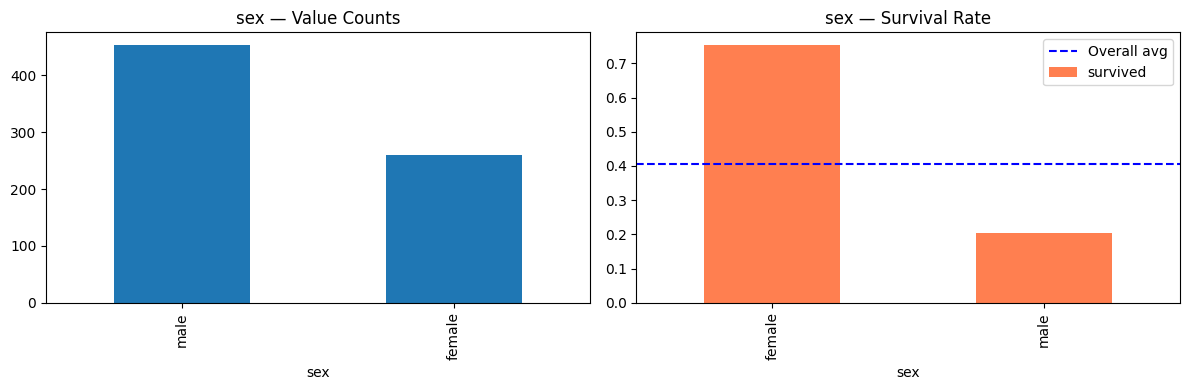

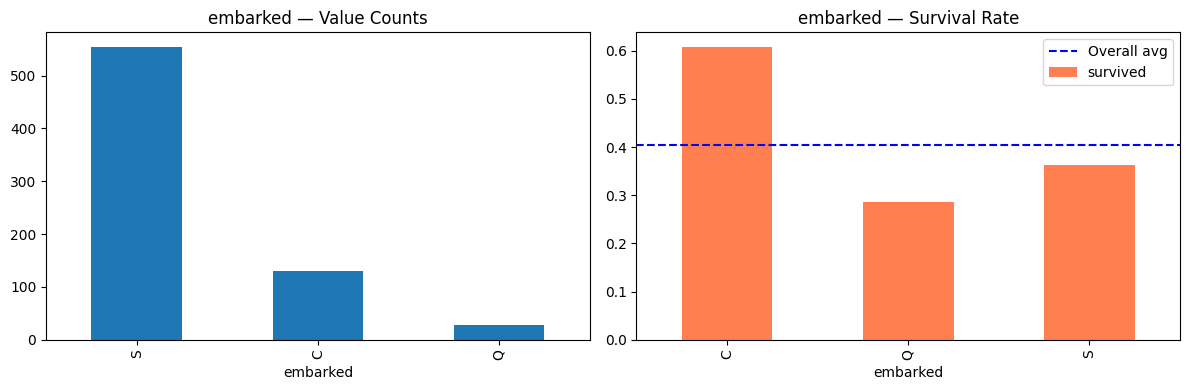

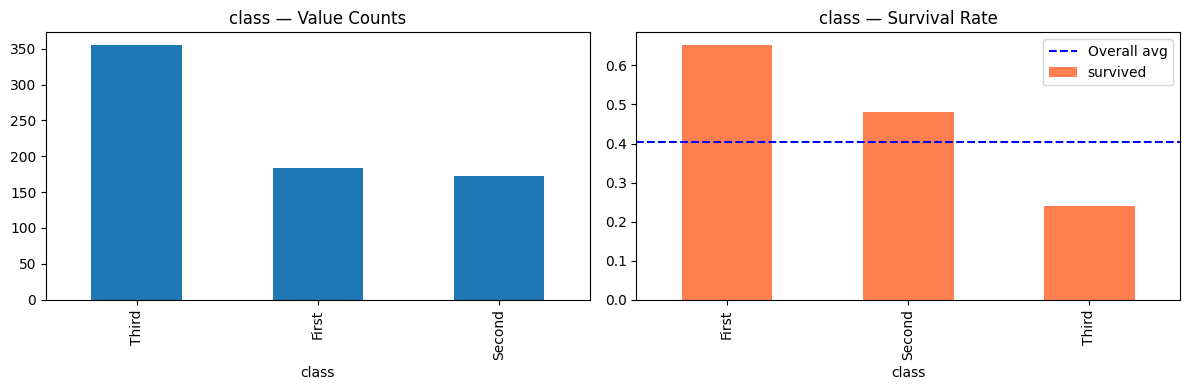

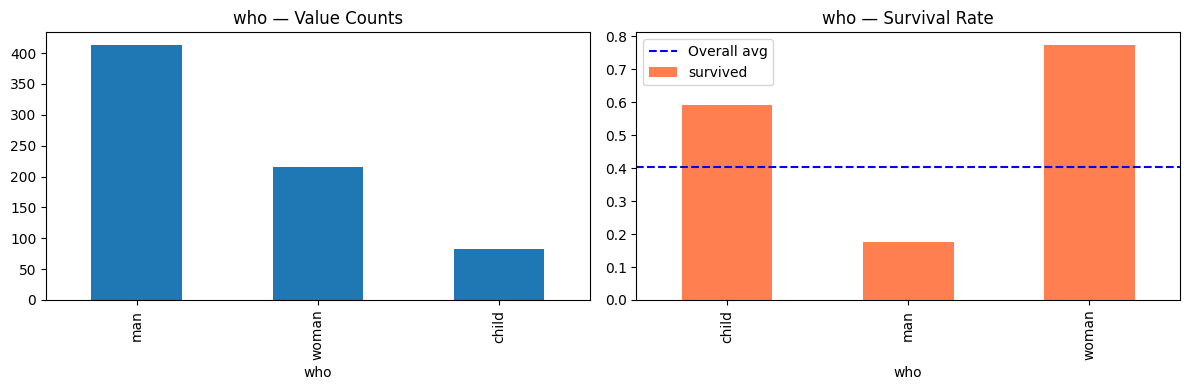

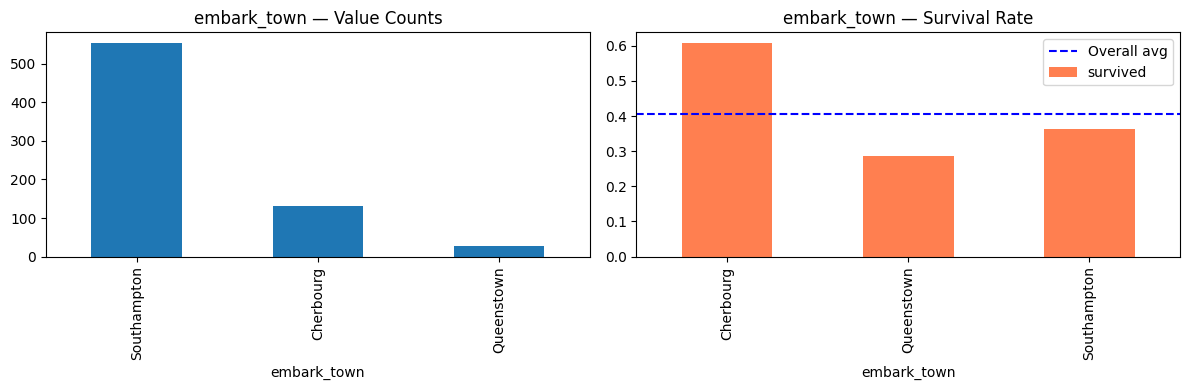

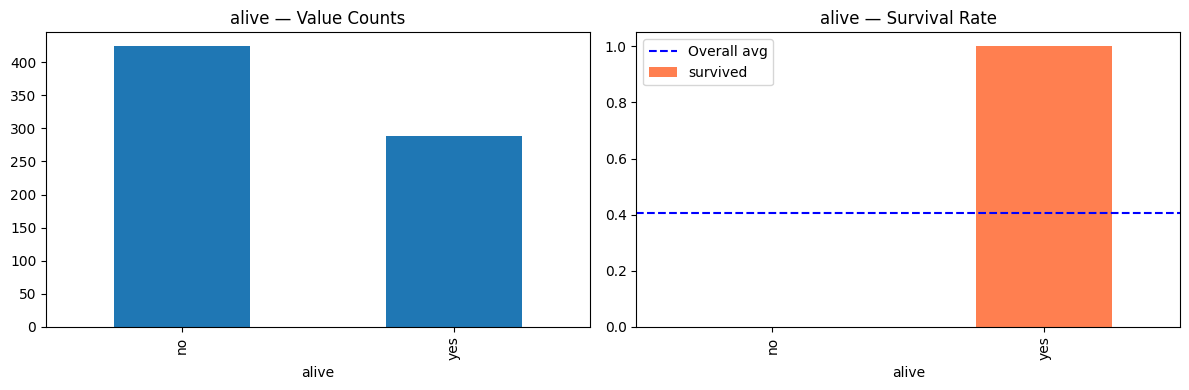

In [22]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Value counts
    df[col].value_counts().plot(kind='bar', ax=axes[0])
    axes[0].set_title(f'{col} — Value Counts')
    
    # Relationship with target
    df.groupby(col)['survived'].mean().plot(kind='bar', 
                                             ax=axes[1], 
                                             color='coral')
    axes[1].set_title(f'{col} — Survival Rate')
    axes[1].axhline(y=df['survived'].mean(), 
                    color='blue', linestyle='--', 
                    label='Overall avg')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

In [23]:
df.head()
col = ['who', 'adult_male', 'sibsp', 'sibsp_log', 'embarked', 'embark_town']
df.drop(col, axis=1, inplace=True)

In [24]:
df.head()
# encoding
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['class'] = df['class'].map({'First': 0, 'Second': 1, 'Third': 2})
df['alive'] = df['alive'].map({'no': 0, 'yes': 1})
df['alone'] = df['alone'].map({False: 1, True: 2})

In [25]:
X = df.drop('survived', axis=1)
y = df['survived']

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# ✅ CORRECT WAY — no leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Learn from train only
X_test_scaled  = scaler.transform(X_test)        # Apply same to test

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

# Pipeline ONLY fits on training data internally
pipe.fit(X_train, y_train)      # Safe ✅
pipe.predict(X_test)            # Safe ✅

array([1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1])

In [28]:
from sklearn.preprocessing import (
    StandardScaler,    # Mean=0, Std=1
    MinMaxScaler,      # Range 0 to 1
    RobustScaler,      # Uses median, good for outliers
)

# When to use which?
# StandardScaler → Normal distribution, no big outliers
# MinMaxScaler   → Need values between 0 and 1 (Neural Nets)
# RobustScaler   → Data has outliers (BEST for most cases)

In [29]:
# Imputing missing values
from sklearn.impute import SimpleImputer

# Numeric imputer
num_imputer = SimpleImputer(strategy='median')

# Categorical imputer
cat_imputer = SimpleImputer(strategy='most_frequent')

In [30]:
from sklearn.preprocessing import (
    OneHotEncoder,    # Creates dummy columns
    OrdinalEncoder,   # Converts to numbers (1,2,3)
    LabelEncoder,     # For target variable only
)

# OneHotEncoder → No order in categories (Sex, Embarked)
# OrdinalEncoder → Categories have order (Low, Mid, High)


In [31]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Load clean Titanic
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Drop useless columns
df.drop(['PassengerId','Name','Ticket','Cabin'], 
        axis=1, inplace=True)

# Features & Target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Identify column types
numeric_cols     = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_cols = ['Sex', 'Embarked', 'Pclass']

print("Numeric    :", numeric_cols)
print("Categorical:", categorical_cols)

Numeric    : ['Age', 'Fare', 'SibSp', 'Parch']
Categorical: ['Sex', 'Embarked', 'Pclass']


In [32]:
# Numeric: Impute → Scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])

In [33]:
from sklearn.preprocessing import RobustScaler

# Categorical: Impute → Encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False))
])

In [34]:
# Merge both pipelines
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,     numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

In [35]:
# Full pipeline = Preprocessing + Model
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

print(full_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['Age', 'Fare', 'SibSp',
                                                   'Parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
  

In [36]:
from sklearn.metrics import (accuracy_score, 
                              classification_report,
                              confusion_matrix)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train — Pipeline handles everything internally
full_pipeline.fit(X_train, y_train)

# Predict
y_pred = full_pipeline.predict(X_test)

# Results
print("=" * 45)
print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print("=" * 45)
print(classification_report(y_test, y_pred,
      target_names=['Died','Survived']))

  Accuracy : 0.8045
              precision    recall  f1-score   support

        Died       0.81      0.89      0.85       110
    Survived       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [37]:
from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold
)

# Stratified = keeps class ratio in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run cross validation on full pipeline
scores = cross_val_score(
    full_pipeline,
    X, y,
    cv=cv,
    scoring='accuracy'
)

print("CV Scores  :", scores.round(4))
print(f"Mean       : {scores.mean():.4f}")
print(f"Std        : {scores.std():.4f}")
print(f"Confidence : {scores.mean():.4f} ± {scores.std():.4f}")

CV Scores  : [0.7877 0.8034 0.7978 0.7809 0.8202]
Mean       : 0.7980
Std        : 0.0136
Confidence : 0.7980 ± 0.0136


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'Random Forest'       : RandomForestClassifier(n_estimators=100),
    'SVM'                 : SVC()
}

print("=" * 45)
print(f"  {'Model':<22} {'Mean':>6}  {'Std':>6}")
print("=" * 45)

results = {}
for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f"  {name:<22} {scores.mean():.4f}  {scores.std():.4f}")

print("=" * 45)
best = max(results, key=lambda k: results[k].mean())
print(f"\n🏆 Best Model: {best}")

  Model                    Mean     Std
  Logistic Regression    0.7980  0.0136
  Random Forest          0.8125  0.0234
  SVM                    0.8215  0.0244

🏆 Best Model: SVM
